<a href="https://colab.research.google.com/github/ancestor9/mathematics-for-machine-learning/blob/main/scripts/w4_stochastic_gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color='blue'> Stochastic Gradient Descent(SGD)
## $y = mx + c$
1. Cost function
2. Gradient descent

<img src='https://miro.medium.com/max/1313/1*CjTBNFUEI_IokEOXJ00zKw.gif' width=700 height=500>

- Stochastic Gradient Descent (SGD) is a **simple yet very efficient approach to fitting linear classifiers and regressors under convex loss functions** such as (linear) Support Vector Machines and Logistic Regression. Even though SGD has been around in the machine learning community for a long time, it has received a considerable amount of attention just recently in the context of large-scale learning.

- SGD has been **successfully applied to large-scale and sparse machine learning problems often encountered in text classification and natural language processing.** Given that the data is sparse, the classifiers in this module easily scale to problems with more than 10^5 training examples and more than 10^5 features.

- Strictly speaking, SGD is **merely an optimization technique and does not correspond to a specific family of machine learning models. It is only a way to train a model.**

- Often, an instance of SGDClassifier or SGDRegressor will have an equivalent estimator in the scikit-learn API, potentially using a different optimization technique. For example, using **SGDClassifier(loss='log') results in logistic regression**, i.e. a model equivalent to LogisticRegression which is fitted via SGD instead of being fitted by one of the other solvers in LogisticRegression. Similarly, SGDRegressor(loss='squared_error', penalty='l2') and Ridge solve the same optimization problem, via different means.

- The **advantages** of Stochastic Gradient Descent are:
   * Efficiency.
   * Ease of implementation (lots of opportunities for code tuning).

- The **disadvantages** of Stochastic Gradient Descent include:
   * SGD requires a number of hyperparameters such as the regularization parameter and the number of iterations.
   * SGD is sensitive to feature scaling.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings(action='ignore')
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

- 편미분 공식은 (편미분 chain rule)

<img src ='https://purnasai.github.io/assets/images/Lr/derive.png' width=300>

<img src='http://2.bp.blogspot.com/-AdV-O-MoZHE/TtLibFTaf9I/AAAAAAAAAVM/aOxUGP7zl98/s1600/gradient+descent+algorithm+OLS.png'>

- https://math.stackexchange.com/questions/3152235/partial-derivative-of-mse-cost-function-in-linear-regression

## **1. Gradient Descent’s Limitations**
- Gradient Descent is a powerful algorithm. But in a real-world scenarios with ever growing datasets, it has **two major limitations**;


1.   Calculating derivatives for the entire dataset is time consuming.
2.   Memory required is proportional to the size of the dataset.


# <font color='purple'> **Stochastic Gradient Descent**

<img src='https://miro.medium.com/max/1324/1*iyL9xWO7YyQGWEC46Gantw.png'>

# <font color='red'> Quiz 5
### x = [1,2,4,3,5], y= [1,3,3,2,5]
### y= a + bx 선형모델을 가정
### 학습율은 0.01, initial random guess a = b = 0
### Stochastic gradient descent 알고리즘으로 20회(iterations =20) 학습한 결과 절편과 기울기값은?

1. 0.25, 0.87
2. 0.23, 0.79
3. 0.22, 0.89
4. 0.27, 0.90
5. 0.23, 0.81

# **Tangent (gradient)**
<img src='https://upload.wikimedia.org/wikipedia/commons/7/7a/Graph_of_sliding_derivative_line.gif'>
<img src='https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR8vlBxxrBTYsTxZrizxRJjNEZbVHtlpd3byQ&usqp=CAU'>

# stochastic-gradient-descent-explained-in-real-life
-  https://towardsdatascience.com/stochastic-gradient-descent-explained-in-real-life-predicting-your-pizzas-cooking-time-b7639d5e6a32

<img src='https://miro.medium.com/max/1400/1*Y0N923n5SFspV4SkzKZSwA.png'>

## **2. SDG 모형**

SGDRegressor(max_iter=30)

선형모델의 절편: [0.24609932], 기울기: [0.83792154]


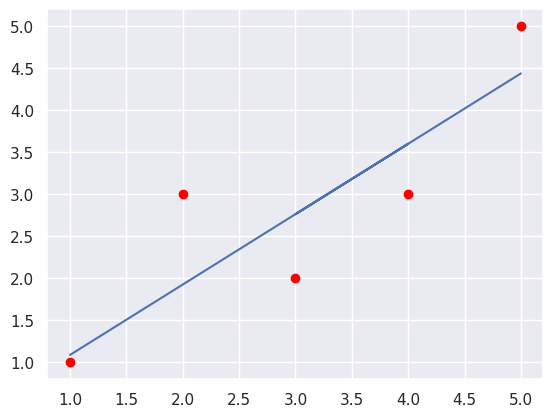

In [2]:
from sklearn import linear_model
X = np.array([1,2,4,3,5])
y = np.array([1,3,3,2,5])
sgd = linear_model.SGDRegressor(max_iter=30)
sgd.fit(X.reshape(-1,1), y)         # 2. 학습하기
yhat = sgd.predict(X.reshape(-1,1)) #  3. 예측
plt.scatter(X, y, color='red')
plt.plot(X, yhat)
print(f'선형모델의 절편: {sgd.intercept_}, 기울기: {sgd.coef_}')

### max_iter을 5, 10, 15, 20으로 fitting

**회귀분석 모형**

선형모델의 절편: 0.3999999999999999, 기울기: [0.8]


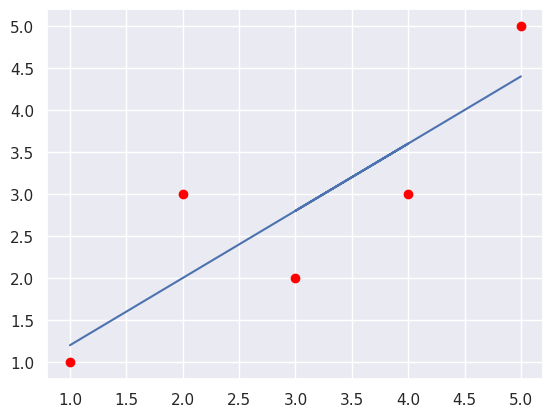

In [3]:
lgr = linear_model.LinearRegression()
yhat = lgr.fit(X.reshape(-1,1), y).predict(X.reshape(-1,1))
plt.scatter(X, y, color='red')
plt.plot(X, yhat)
print(f'선형모델의 절편: {lgr.intercept_}, 기울기: {lgr.coef_}')

In [4]:
from sklearn import metrics
metrics.mean_squared_error(y, sgd.predict(X.reshape(-1,1)))
print('\n')
metrics.mean_squared_error(y, lgr.predict(X.reshape(-1,1)))

0.4844869899308656

0.4800000000000001

## 예제

Text(0.5, 0, '$x_1$')

Text(0, 0.5, '$y$')

(np.float64(0.0), np.float64(2.0), np.float64(0.0), np.float64(15.0))

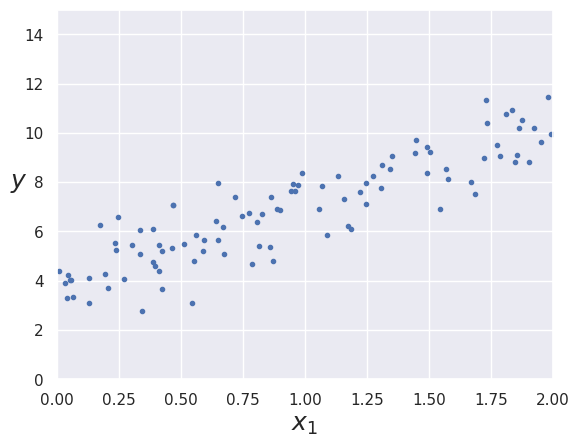

In [5]:
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)
plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 2, 0, 15])
plt.show()

### **2.1. 선형대수(numpy) 예측**
<img src = 'https://wikimedia.org/api/rest_v1/media/math/render/svg/704b31aa61dfc93d672f15bf02aa6d168be49643' width=600>

-
<img src = 'https://wikimedia.org/api/rest_v1/media/math/render/svg/e286875158615d5647351c312f4609a125a5d943' width=350>

<img src = 'https://wikimedia.org/api/rest_v1/media/math/render/svg/fb161a08d2371663a73aae304a7ba910b7e9776a' width=250>

Text(0.5, 0, '$x_1$')

Text(0, 0.5, '$y$')

(np.float64(0.0), np.float64(2.0), np.float64(0.0), np.float64(12.0))

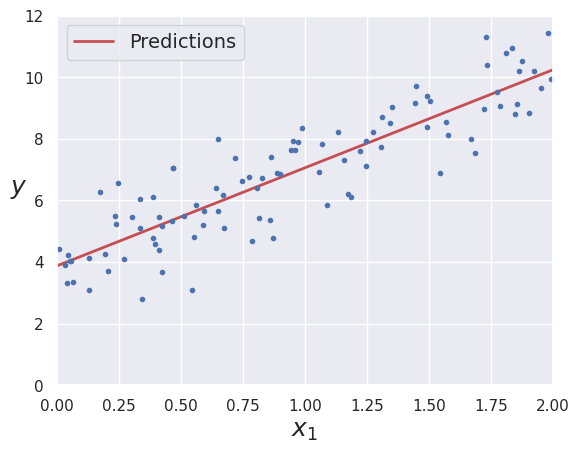

In [6]:
X_b = np.c_[np.ones((100, 1)), X]  # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]  # add x0 = 1 to each instance
y_predict = X_new_b.dot(theta_best)
plt.plot(X_new, y_predict, "r-", linewidth=2, label="Predictions")
plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.axis([0, 2, 0, 12])

In [7]:
print(f'절편: {theta_best[0]}, 기울기: {theta_best[1]}')

절편: [3.87614251], 기울기: [3.18268047]


### **2.2 Scikit-learn Linear regression API로 예측**

In [8]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
print(f'절편: {lin_reg.intercept_}, 기울기: {lin_reg.coef_}')

LinearRegression()

절편: [3.87614251], 기울기: [[3.18268047]]


### **2.3. SGD로 예측**

In [9]:
X_b = np.c_[np.ones((100, 1)), X]  # add x0 = 1 to each instance
X[0:3]
print('\n')
X_b[0:3]

array([[0.00953993],
       [0.78777258],
       [0.06365733]])

array([[1.        , 0.00953993],
       [1.        , 0.78777258],
       [1.        , 0.06365733]])

Text(0.5, 0, '$x_1$')

Text(0, 0.5, '$y$')

(np.float64(0.0), np.float64(2.0), np.float64(0.0), np.float64(15.0))

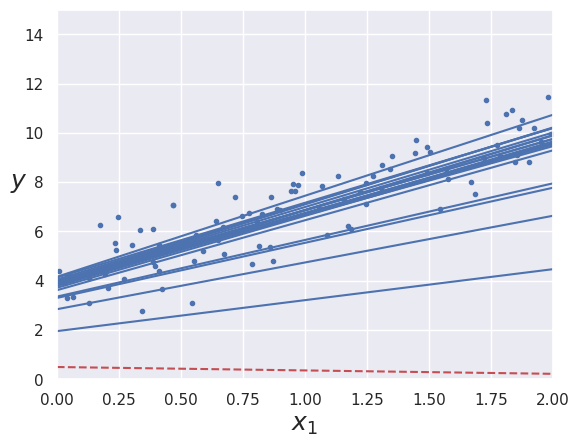

In [10]:
theta_path_sgd = []
m = len(X_b)
np.random.seed(42)

n_epochs = 50
t0, t1 = 5, 50  # learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

theta = np.random.randn(2,1)  # random initialization

for epoch in range(n_epochs):
    for i in range(m):
        if epoch == 0 and i < 20:
            y_predict = X_new_b.dot(theta)
            style = "b-" if i > 0 else "r--"
            plt.plot(X_new, y_predict, style)
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * m + i)
        theta = theta - eta * gradients
        theta_path_sgd.append(theta)

plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 2, 0, 15])
plt.show()

In [11]:
theta_path_sgd[-1]
print('\n')
print(f'절편: {theta[0]}, 기울기: {theta[1]}')

array([[3.84183076],
       [3.1770677 ]])



절편: [3.84183076], 기울기: [3.1770677]


https://www.kaggle.com/ryanholbrook/stochastic-gradient-descent
<img src='https://i.imgur.com/rFI1tIk.gif'>

## **3. 사이킷런의 3가지 선형모델 알고리즘 (fit, predict) 비교**
#### 데이터 불러오기

In [12]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
housing.feature_names.extend(housing.target_names)
df = pd.DataFrame(np.c_[housing.data, housing.target], columns = housing.feature_names)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [13]:
df.corr()[-1:]
X = df[['MedInc', 'AveRooms']]
y = df['MedHouseVal']

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.02465,-0.023737,-0.14416,-0.045967,1.0


### **3.1. Ordinary Least Squares (statisitc models API)**

In [14]:
import statsmodels.api as sm
X = sm.add_constant(X) # 절편 포함
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.479
Model:                            OLS   Adj. R-squared:                  0.479
Method:                 Least Squares   F-statistic:                     9502.
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:58:56   Log-Likelihood:                -25505.
No. Observations:               20640   AIC:                         5.102e+04
Df Residuals:                   20637   BIC:                         5.104e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5950      0.016     36.836      0.0

### **3.2. Regression (scikit learn API)**

In [15]:
from sklearn.metrics import mean_squared_error, r2_score
regr = linear_model.LinearRegression(fit_intercept=True)
regr.fit(X, y)
y_pred = regr.predict(X)
print(f'절편: {regr.intercept_}, 기울기{regr.coef_} \n')
print('Mean squared error: %.2f'% mean_squared_error(y, y_pred))
print('Coefficient of determination: %.2f' % r2_score(y, y_pred))

LinearRegression()

절편: 0.5949584738121947, 기울기[ 0.          0.43416302 -0.03811061] 

Mean squared error: 0.69
Coefficient of determination: 0.48


### **3.3 Stochastic gradient descent**

In [16]:
from sklearn.linear_model import SGDRegressor       # 알고리즘 불러오고 데이터 준비하기
model = SGDRegressor(max_iter=100)                  # 1. 알고리즘 객체화 (max_iter --> aka epochs)
model.fit(X, y)                                      #  2. 학습하기
model.get_params()                                   #  학습한 모델 내부 저장
y_pred = model.predict(X)                            # 3. 예측하기 (unseen data)

SGDRegressor(max_iter=100)

{'alpha': 0.0001,
 'average': False,
 'early_stopping': False,
 'epsilon': 0.1,
 'eta0': 0.01,
 'fit_intercept': True,
 'l1_ratio': 0.15,
 'learning_rate': 'invscaling',
 'loss': 'squared_error',
 'max_iter': 100,
 'n_iter_no_change': 5,
 'penalty': 'l2',
 'power_t': 0.25,
 'random_state': None,
 'shuffle': True,
 'tol': 0.001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [18]:
print(f'모델의 Mean squared error는 :{round(mean_squared_error(y, y_pred), 4)}')
print(f'절편: {model.intercept_}, 기울기: {model.coef_}')

모델의 Mean squared error는 :0.7163
절편: [0.29960941], 기울기: [ 0.29539462  0.45323497 -0.07480443]


# End